# Nonlinear Time-History on MDOF System

## Introduction

This Jupyter Notebook provides a structured workflow for performing a nonlinear time-history analyses (NLTHA) on multi-degree-of-freedom (MDOF) stick-and-mass structural models using a single record. By combining functions for MDOF modeling and dynamic analysis, the notebook enables the setup, execution, and post-processing of structural responses under earthquake loading.

The main goals of this notebook:

1. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including mass, heights and nonlinear response characteristics at each degree of freedom

2. **Run Nonlinear Time-History Analysis (NLTHA) in OpenSees**: Simulate the dynamic response of MDOF structures under time-dependent inputs, such as ground motion records, to realistically assess structural behavior and response metrics (e.g., peak storey drifts, peak floor accelerations) under loading conditions and extract critical response metrics and model information.

3. **Export Response Quantities from NLTHA**: Postprocess response quantities from NLTHA in a ready-to-use format by other OQ-VMTK modules and functions

4. **Visualise Seismic Demands from NLTHA**: Visualise the seismic demand profiles (i.e., the distribution of peak storey drift and peak floor acceleration values along the height of the idealised MDOF model).

## Initialize Libraries ##

In [ ]:
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openquake.vmtk.units import units
from openquake.vmtk.calibration import calibrate_model
from openquake.vmtk.modeller import modeller
from openquake.vmtk.plotter import plotter
from openquake.vmtk.utilities import export_to_pkl

## Define Directories ##

In [2]:
# Define the directory of the ground-motion records
gm_directory  = './in/records'            

# Define the main output directory
nrha_directory = './out'  
os.makedirs(nrha_directory, exist_ok=True)

## Calibrate and Compile an MDOF Model based on SDOF Capacity ##

In [ ]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array(
    [[0.00060789, 0.00486316, 0.02420000, 0.04353684],  # spectral displacement [m]
     [0.10315200, 0.20630401, 0.12378241, 0.12502023]]  # spectral acceleration [g]
).T

# Soft-storey mechanism flag
isSOS = False

# Degradation flag
mdof_degradation = False

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=isSOS,
    storey_heights=storey_heights,
    verbose=False,
)

## Setting Up, Running NLTHA and Exporting Analysis ##

The following parameters are required to run a nonlinear time-history analysis using the `do_nrha_analysis` method of the `modeller` class. The model must have been compiled (`compile_model`), and gravity and modal analyses must have been completed before calling this method.

- **`fnames`**: List of file paths to the ground motion acceleration records. One file = X-direction loading only; two files = simultaneous bi-directional X and Y loading. Each file should contain a single column of accelerations sampled at `dt_gm`.
- **`dt_gm`**: Time-step of the ground motion record in seconds.
- **`sf`**: Scale factor applied to the ground motion. Set `sf = units.g` (9.81 m/s²) when records are in units of g, as required by OpenSees.
- **`t_max`**: Total duration of the analysis in seconds. Typically set to the total duration of the ground motion record.
- **`dt_ansys`**: Integration time-step for the Newmark solver in seconds. Typically equal to `dt_gm`; reduce if convergence difficulties arise.
- **`pFlag`** *(optional, default `True`)*: Prints progress and summary to the console when `True`.
- **`xi`** *(optional, default `0.05`)*: Viscous damping ratio applied as Rayleigh damping (5% = 0.05).
- **`save_animation_path`** *(optional)*: File path to export the NRHA animation (`.gif` or `.mp4`). Set to `None` to skip animation generation.
- **`drift_thresholds`** *(optional)*: List of inter-storey drift ratio thresholds (dimensionless, e.g. `[0.0015, 0.003, 0.0045, 0.0135]`) used to colour-code the animation by damage state. Colours progress from blue (no damage) to red (collapse).

The method returns the following outputs:

- **`control_nodes`**: List of all node tags (base node first, then floor nodes in ascending order).
- **`conv_index`**: `0` = analysis completed successfully; `-1` = collapse detected or non-convergence.
- **`peak_drift`**: Array `(n_storeys × 2)` of peak inter-storey drift ratios. Column 0 = X, column 1 = Y.
- **`peak_accel`**: Array `(n_nodes × 2)` of peak absolute floor accelerations in g. Row 0 = base (PGA); rows 1–N = floors. Column 0 = X, column 1 = Y.
- **`max_peak_drift`**: Maximum peak inter-storey drift ratio across all storeys and directions.
- **`max_peak_drift_dir`**: Direction (`'X'` or `'Y'`) of the maximum peak drift.
- **`max_peak_drift_loc`**: 1-based storey number of the maximum peak drift.
- **`max_peak_accel`**: Maximum peak absolute floor acceleration in g across all floors and directions.
- **`max_peak_accel_dir`**: Direction (`'X'` or `'Y'`) of the maximum peak acceleration.
- **`max_peak_accel_loc`**: 0-based floor index of the maximum peak acceleration (0 = base).
- **`peak_disp`**: Array `(n_nodes × 2)` of peak relative floor displacements in metres.
- **`storey_hyst_energy`**: Array `(n_storeys,)` of dissipated hysteretic energy per storey in kN·m.
- **`total_hyst_energy`**: Total dissipated hysteretic energy across all storeys in kN·m.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


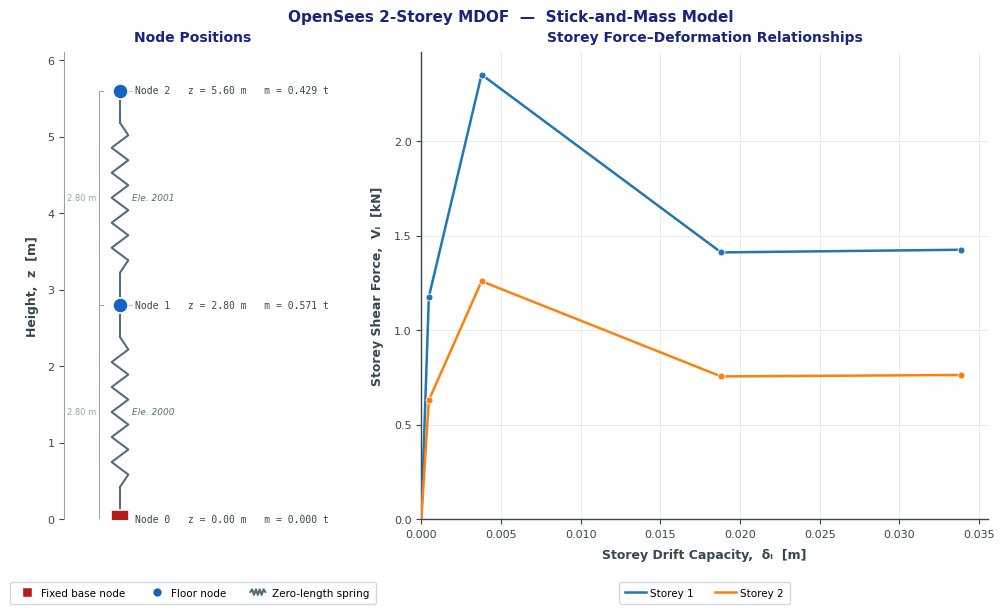

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~

Generating NRHA animation...

Saving NRHA animation (41 frames) to: out/nrha_animation.gif
Peak drift values in X-direction: [0.07752482 0.00484042] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [0.8811615  0.48805602 0.35823506] g
Peak acceleration values in Y-direction: [0. 0. 0.] g
Maximum peak storey drift value of 0.07752481837854269 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.8811614999939373 encountered in X direction on storey # 0
ANALYSIS COMPLETED!


In [4]:
# Initialise MDOF storage lists
conv_index_list = []               # List for convergence indices
peak_disp_list  = []               # List for peak floor displacement (returns all peak values along the building height)
peak_drift_list = []               # List for peak storey drift (returns all peak values along the building height)
peak_accel_list = []               # List for peak floor acceleration (returns all peak values along the building height)
max_peak_drift_list = []           # List for maximum peak storey drift (returns the maximum value) 
max_peak_drift_dir_list = []       # List for maximum peak storey drift directions
max_peak_drift_loc_list = []       # List for maximum peak storey drift locations
max_peak_accel_list = []           # List for maximum peak floor acceleration (returns the maximum value)
max_peak_accel_dir_list = []       # List for maximum peak floor acceleration directions 
max_peak_accel_loc_list = []       # List for maximum peak floor acceleration locations
total_hyst_energy_list = []        # List for total hysteretic energy dissipated
storey_hyst_energy_list = []       # List for storey-based hysteretic energy dissipated

# Initialise the modeller class and compile the MDOF model  
model = modeller(number_storeys,
                 storey_heights,
                 floor_masses,
                 storey_drifts,
                 storey_forces*units.g,
                 mdof_degradation)                                                                
model.compile_model()                                                                             

# Visualise the model
model.plot_model(pFlag = True,
                 export_path = './out/mdof_model.png')   

# Do gravity analysis for system equilibrium
model.do_gravity_analysis()                                                                       

# Do modal analysis
num_modes = 3
T, phi = model.do_modal_analysis(num_modes = num_modes,
                                plot_modes = None)                                                # Do modal analysis and get period of vibration (Essential step for running NLTHA)

# Define ground motion objects
fnames = [os.path.join(gm_directory,'acc.csv')]                                                   # Ground-motion record names
fdts   =  os.path.join(gm_directory,'dts.csv')                                                    # Ground-motion time-step names 
dt_gm = pd.read_csv(fdts, header=None)[pd.read_csv(fdts,header=None).columns[0]].loc[1]-\
        pd.read_csv(fdts, header=None)[pd.read_csv(fdts,header=None).columns[0]].loc[0]           # Ground-motion time-step
t_max = pd.read_csv(fdts)[pd.read_csv(fdts).columns[0]].iloc[-1]                                  # Ground-motion duration
    
# Define analysis params
dt_ansys = dt_gm                                                          # Set the analysis time-step
sf = 0.5*units.g                                                          # Set the scaling factor (Note: if records are in g, an additional scaling factor of 9.81 m/s2 must be used to be consistent with opensees) 

# Run the analysis 
control_nodes, conv_index, peak_drift, peak_accel, max_peak_drift, max_peak_drift_dir, max_peak_drift_loc, max_peak_accel, max_peak_accel_dir, max_peak_accel_loc, peak_disp, storey_hyst_energy, total_hyst_energy = model.do_nrha_analysis(fnames, 
                                                                                                                                                                                                                                             dt_gm, 
                                                                                                                                                                                                                                             sf, 
                                                                                                                                                                                                                                             t_max, 
                                                                                                                                                                                                                                             dt_ansys,
                                                                                                                                                                                                                                             pFlag=False,
                                                                                                                                                                                                                                             xi = 0.05,
                                                                                                                                                                                                                                             save_animation_path='out/nrha_animation.gif',       # Note: Analysis will take longer to run due to the generation of the animated NRHA
                                                                                                                                                                                                                                             drift_thresholds=[0.0015, 0.0030, 0.0045, 0.0135])  # Note: The damage thresholds are arbitrary and are not associated with any limit state analysis
# Print statements
print('Peak drift values in X-direction:', peak_drift[:,0], 'rad') # Peak drift values in the X-direction
print('Peak drift values in Y-direction:', peak_drift[:,1], 'rad') # Peak drift values in the Y-direction (Zeros due to uni-directional loading)
print('Peak acceleration values in X-direction:', peak_accel[:,0], 'g') # Peak acceleration values in the X-direction
print('Peak acceleration values in Y-direction:', peak_accel[:,1], 'g') # Peak acceleration values in the Y-direction
print('Maximum peak storey drift value of', max_peak_drift, 'encountered in', max_peak_drift_dir ,'direction', 'on storey #', max_peak_drift_loc)       # Reporting
print('Maximum peak floor acceleration value of', max_peak_accel, 'encountered in', max_peak_accel_dir ,'direction', 'on storey #', max_peak_accel_loc) # Reporting

# Store the analysis
conv_index_list.append(conv_index)
peak_drift_list.append(peak_drift)
peak_accel_list.append(peak_accel)
peak_disp_list.append(peak_disp)
max_peak_drift_list.append(max_peak_drift)
max_peak_drift_dir_list.append(max_peak_drift_dir)
max_peak_drift_loc_list.append(max_peak_drift_loc)
max_peak_accel_list.append(max_peak_accel)
max_peak_accel_dir_list.append(max_peak_accel_dir)
max_peak_accel_loc_list.append(max_peak_accel_loc)
storey_hyst_energy_list.append(storey_hyst_energy)
total_hyst_energy_list.append(total_hyst_energy)

# Store the analysis results in a dictionary compatible with required input from other OQ-VMTK modules and functions
ansys_dict = {}
labels = ['T','control_nodes', 'conv_index_list',
          'peak_drift_list','peak_accel_list',
          'max_peak_drift_list', 'max_peak_drift_dir_list', 
          'max_peak_drift_loc_list','max_peak_accel_list',
          'max_peak_accel_dir_list','max_peak_accel_loc_list',
          'peak_disp_list', 'total_hyst_energy_list', 'storey_hyst_energy_list']

for i, label in enumerate(labels):
    ansys_dict[label] = vars()[f'{label}']

# Export the analysis output variable to a pickle file using the "export_to_pkl" function from "utilities"
export_to_pkl(os.path.join(nrha_directory,'nrha_ansys_out.pkl'), ansys_dict) 

print('ANALYSIS COMPLETED!')

## Plot the Seismic Demand Profiles: Drifts and Accelerations ##

The following parameters are required to plot the seismic demand profiles using the `plot_demand_profiles` method of the `plotter` class. The method produces a two-panel figure showing peak inter-storey drift (%) and peak absolute floor acceleration (g) plotted against floor number.

- **`peak_drift_list`**: List of `peak_drift` arrays as returned by `do_nrha_analysis`, one per analysis run. Each array has shape `(n_storeys × 2)`; only column 0 (X direction) is plotted. Values are converted from ratio to percentage internally.
- **`peak_accel_list`**: List of `peak_accel` arrays as returned by `do_nrha_analysis`, one per analysis run. Each array has shape `(n_nodes × 2)`; only column 0 (X direction) is plotted. Values are already in g.
- **`control_nodes`**: List of node tags as returned by `do_nrha_analysis`. Used to set the floor-number axis ticks.
- **`title`** *(optional)*: Figure title string. Defaults to `'Seismic Demand Profiles'`.
- **`pFlag`** *(optional, default `True`)*: Saves and displays the figure when `True`; closes it without saving when `False`.
- **`export_path`** *(optional)*: Full file path including filename and extension to save the figure. Missing directories are created automatically.

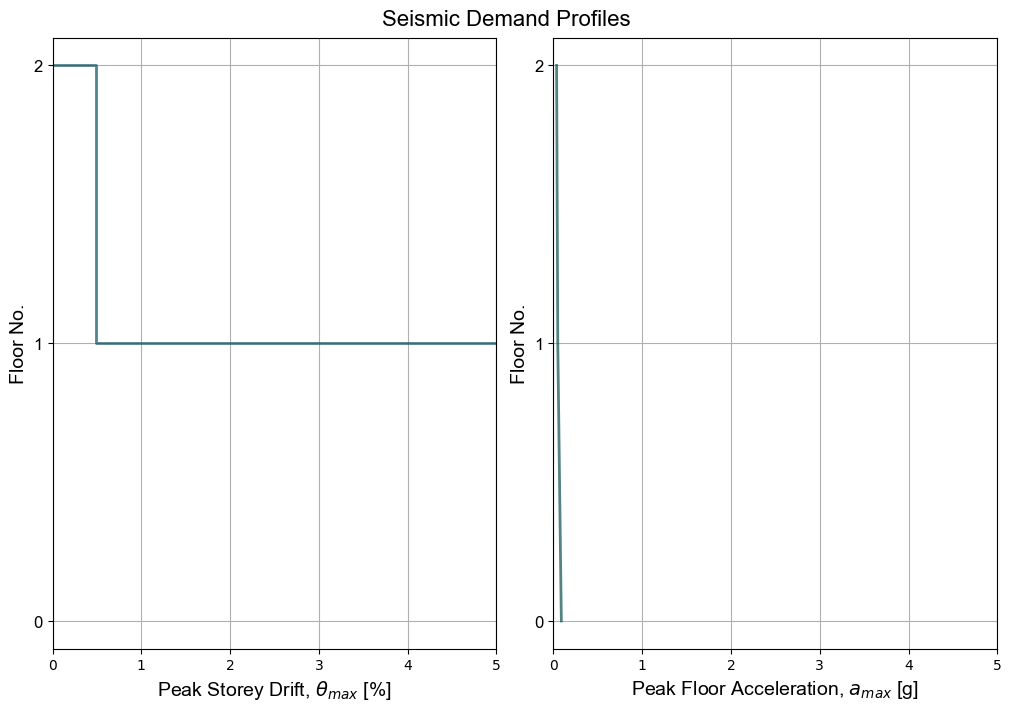

In [5]:
# Initialise the plotter class
pl = plotter()

# Visualise the seismic demands
pl.plot_demand_profiles(ansys_dict['peak_drift_list'], 
                        ansys_dict['peak_accel_list'], 
                        ansys_dict['control_nodes'], 
                        title = 'Seismic Demand Profiles',
                        pFlag = True,
                        export_path = 'out/demand_profiles.png') # The y-axis values of drift and acceleration are converted to % and g automatically by the plotter